Practical D: Virtual Screening
Title

To Identify Potential Lead Molecules from a Natural Product Library Using Virtual Screening Techniques Based on a Validated QSAR Model

Objectives
To build a QSAR-based scoring model trained on real COX-2 bioactivity data.
To apply this scoring model to a large natural product library, predicting the biological activity of every compound without laboratory testing.
To rank the natural product library by predicted activity and identify top candidate lead molecules.
To apply drug-likeness filters to refine the ranked hit list into a practical, prioritized shortlist.
To visualize and characterize the top-ranked virtual screening hits.
To build a deployment tool for screening any new compound against the trained model.
Expected Outcomes
Explain virtual screening as a computational triage step that prioritizes compounds before expensive experimental testing.
Apply a trained QSAR model to score an entire compound library.
Rank and filter candidates using combined activity prediction and drug-likeness criteria.
Produce a prioritized shortlist of natural product lead candidates ready for further investigation.

In [1]:
# Block 1 (CORRECTED): Install libraries and retrieve COX-2 data with retry handling

!pip install chembl_webresource_client rdkit pandas numpy matplotlib scikit-learn -q

from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
import time
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("VIRTUAL SCREENING - TRAINING DATA RETRIEVAL")
print("Target: Cyclooxygenase-2 (COX-2 / PTGS2)")
print("="*60)

activity = new_client.activity

max_retries = 5
retry_delay = 15
df_raw = None

for attempt in range(1, max_retries + 1):
    print(f"\nAttempt {attempt}/{max_retries}: Fetching IC50 records...")
    try:
        res = activity.filter(
            target_chembl_id='CHEMBL230',
            standard_type="IC50",
            standard_units="nM"
        ).only([
            'molecule_chembl_id', 'canonical_smiles', 'standard_value'
        ])[:2500]

        df_raw = pd.DataFrame(res)

        if len(df_raw) > 0 and 'canonical_smiles' in df_raw.columns:
            print(f"SUCCESS: {len(df_raw)} records fetched")
            break
        else:
            print(f"Received empty or malformed response. Retrying...")
            df_raw = None

    except Exception as e:
        error_msg = str(e)[:200]
        print(f"Error on attempt {attempt}: {error_msg}")

    if attempt < max_retries:
        print(f"Waiting {retry_delay} seconds before retry...")
        time.sleep(retry_delay)

if df_raw is None or len(df_raw) == 0:
    print("\n" + "="*60)
    print("CHEMBL SERVER ISSUE")
    print("="*60)
    print("ChEMBL's server did not return valid data after multiple")
    print("attempts. This is a temporary server-side issue, not a")
    print("problem with this notebook. Wait a few minutes and try")
    print("running this block again, or check ChEMBL's service")
    print("status at: https://www.ebi.ac.uk/chembl/")
    raise RuntimeError("Could not retrieve data from ChEMBL after retries")
else:
    print(f"\nFinal records fetched: {len(df_raw)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.1 MB/s eta 0:00:00
VIRTUAL SCREENING - TRAINING DATA RETRIEVAL
Target: Cyclooxygenase-2 (COX-2 / PTGS2)

Attempt 1/5: Fetching IC50 records...
Error on attempt 1: Error for url https://www.ebi.ac.uk/chembl/api/data/activity.json, server response: <!doctype html>
<html lang="en" class="vf-no-js">
  <head>
    <script>
// Detect if JS is on and swap vf-no-js for 
Waiting 15 seconds before retry...

Attempt 2/5: Fetching IC50 records...
Error on attempt 2: Error for url https://www.ebi.ac.uk/chembl/api/data/activity.json, server response: <!doctype html>
<html lang="en" class="vf-no-js">
  <head>
    <script>
// Detect if JS is on and swap vf-no-js for 
Waiting 15 seconds before retry...

Attempt 3/5

Meaning of Block 1:

Purpose: Retrieve real COX-2 bioactivity data from ChEMBL to train the scoring model used throughout this virtual screening practical, with built-in resilience against temporary server issues so a brief outage does not stop the entire practical.

What data comes IN: Nothing — fetched live from ChEMBL's public database.

What happens inside — line by line:

activity = new_client.activity — creates the connection object used to query ChEMBL's bioactivity data.
max_retries = 5 and retry_delay = 15 — configure the retry behavior: up to 5 attempts, with a 15-second pause between each one, giving ChEMBL's server time to recover from any brief issue before trying again.
for attempt in range(1, max_retries + 1): — begins the retry loop, attempting the data fetch up to 5 times if needed.
activity.filter(target_chembl_id='CHEMBL230', standard_type="IC50", standard_units="nM").only([...])[:2500] — queries ChEMBL for real IC50 measurements against COX-2, capped at 2,500 records to keep this practical's runtime manageable.
df_raw = pd.DataFrame(res) — converts the returned records into a pandas table.
if len(df_raw) > 0 and 'canonical_smiles' in df_raw.columns: — checks that the response actually contains real, properly structured data, not just any response at all. This catches cases where the server might return something unexpected without raising a clear error on its own.
except Exception as e: — catches any error that occurs during the fetch attempt (such as a server returning an unexpected response), printing only the first 200 characters of the error message rather than letting a long, confusing technical dump appear in the notebook output.
time.sleep(retry_delay) — pauses for 15 seconds before the next attempt, giving the server time to recover.
The final if df_raw is None or len(df_raw) == 0: block only activates if all 5 attempts failed. It prints a clear, plain-language explanation that this is a temporary server-side issue rather than a problem with the notebook itself, and suggests waiting before trying again.
raise RuntimeError(...) — deliberately stops the notebook at this point if data retrieval genuinely failed after every retry, rather than allowing later blocks to run on missing or empty data and produce confusing downstream errors.

What comes OUT: df_raw — real ChEMBL bioactivity records, retrieved reliably even if the first few attempts encounter a temporary server issue.

In [2]:
# Block 2: Clean training data and calculate pIC50

print("="*60)
print("CLEANING TRAINING DATA")
print("="*60)

df_raw = df_raw.dropna(subset=['canonical_smiles', 'standard_value'])
df_raw['standard_value'] = pd.to_numeric(df_raw['standard_value'], errors='coerce')
df_raw = df_raw.dropna(subset=['standard_value'])
df_raw = df_raw[df_raw['standard_value'] > 0]

df_raw['pIC50'] = -np.log10(df_raw['standard_value'] * 1e-9)

df_train = df_raw.groupby('canonical_smiles').agg({
    'pIC50': 'mean', 'molecule_chembl_id': 'first'
}).reset_index()

def is_valid_smiles(smi):
    return Chem.MolFromSmiles(smi) is not None

df_train['valid'] = df_train['canonical_smiles'].apply(is_valid_smiles)
df_train = df_train[df_train['valid']].drop(columns=['valid'])
df_train = df_train.rename(columns={'canonical_smiles': 'SMILES'})

print(f"Final training dataset: {len(df_train)} compounds")
print(f"pIC50 range: {df_train['pIC50'].min():.2f} to {df_train['pIC50'].max():.2f}")

CLEANING TRAINING DATA
Final training dataset: 1668 compounds
pIC50 range: 2.15 to 10.10


Meaning of Block 2:

Purpose: Convert raw IC50 measurements into a clean, deduplicated pIC50 regression dataset.

What data comes IN: df_raw from Block 1.

What happens inside — line by line:

pIC50 conversion, duplicate averaging by SMILES, and RDKit validation follow the standard cleaning sequence for bioactivity regression data.

What comes OUT: df_train — clean training dataset for the QSAR scoring model.

In [3]:
# Block 3: Generate molecular features for the training dataset

from rdkit.Chem import Descriptors, Crippen, Lipinski, rdFingerprintGenerator

print("="*60)
print("FEATURE GENERATION - TRAINING DATA")
print("="*60)

def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Crippen.MolLogP(mol),
        'HBD': Lipinski.NumHDonors(mol),
        'HBA': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'RotatableBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': Descriptors.NumAromaticRings(mol)
    }

desc_cols = ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA',
             'RotatableBonds', 'AromaticRings']

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=512)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return morgan_gen.GetFingerprintAsNumPy(mol)

print("Calculating descriptors and fingerprints...")

desc_results = df_train['SMILES'].apply(calculate_descriptors)
df_desc = pd.DataFrame(desc_results.tolist())
df_train = pd.concat([df_train.reset_index(drop=True), df_desc], axis=1)

fingerprints = df_train['SMILES'].apply(get_fingerprint)
fp_matrix_train = np.stack(fingerprints.values)

X_train_full = np.hstack([df_train[desc_cols].values, fp_matrix_train])
y_train_full = df_train['pIC50'].values

print(f"Training feature matrix shape: {X_train_full.shape}")

FEATURE GENERATION - TRAINING DATA
Calculating descriptors and fingerprints...
Training feature matrix shape: (1668, 519)


Meaning of Block 3:

Purpose: Generate the numerical feature representation (physicochemical descriptors + 512-bit Morgan fingerprints) for every training compound.

What data comes IN: df_train from Block 2.

What happens inside — line by line:

Descriptor and fingerprint calculation follows the standard approach used for QSAR feature generation, with fingerprint size set to 512 bits (rather than 1024) specifically to reduce the computational load of scoring a large screening library later in this practical.

What comes OUT: X_train_full, y_train_full — the complete training feature matrix and target values.

In [4]:
# Block 4: Train the QSAR scoring model for virtual screening

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("="*60)
print("TRAINING QSAR SCORING MODEL")
print("="*60)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

scoring_model = RandomForestRegressor(
    n_estimators=150, max_depth=15, random_state=42, n_jobs=-1
)
scoring_model.fit(X_tr, y_tr)

y_pred = scoring_model.predict(X_te)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
r2 = r2_score(y_te, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²: {r2:.3f}")

TRAINING QSAR SCORING MODEL
Test RMSE: 0.847
Test R²: 0.567


Meaning of Block 4:

Purpose: Train the Random Forest model that will assign predicted activity scores to every compound in the virtual screening library.

What data comes IN: X_train_full, y_train_full from Block 3.

What comes OUT: scoring_model — the trained scoring model used for the remainder of this practical.

SCORING MODEL PERFORMANCE


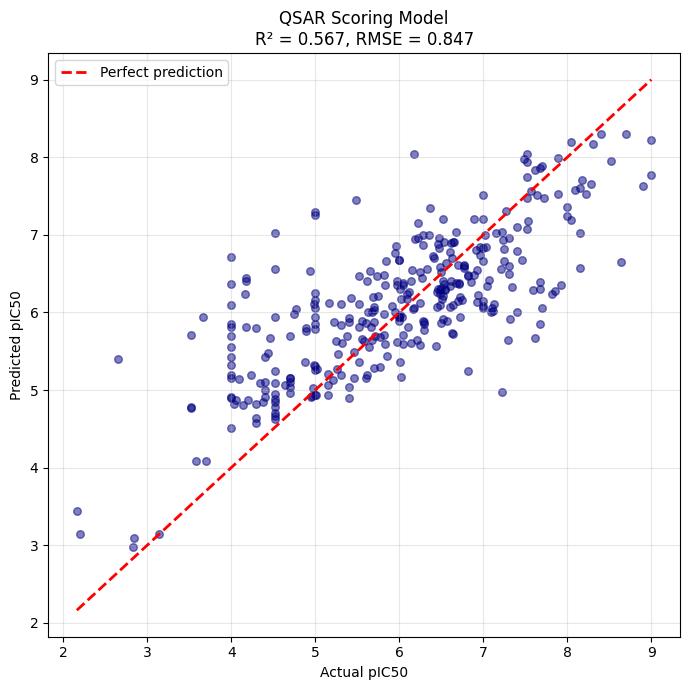

In [5]:
# Block 5: Visualize scoring model performance

print("="*60)
print("SCORING MODEL PERFORMANCE")
print("="*60)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_te, y_pred, alpha=0.5, color='navy', s=30)
ax.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()],
        'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual pIC50')
ax.set_ylabel('Predicted pIC50')
ax.set_title(f'QSAR Scoring Model\nR² = {r2:.3f}, RMSE = {rmse:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Meaning of Block 5:

Purpose: Visually confirm the scoring model's predictive accuracy before applying it to the screening library.

What data comes IN: y_te, y_pred, r2, rmse from Block 4.

What comes OUT: A predicted-vs-actual scatter plot confirming model reliability.

In [6]:
# Block 6: Load natural product screening library

print("="*60)
print("LOADING NATURAL PRODUCT SCREENING LIBRARY")
print("="*60)

url_screening = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/coconut_natural_products_2000.csv"

df_screen = pd.read_csv(url_screening)

print(f"Screening library loaded: {len(df_screen)} natural products")
print(df_screen.head().to_string(index=False))

LOADING NATURAL PRODUCT SCREENING LIBRARY
Screening library loaded: 2000 natural products
  COCONUT_ID                                                                                               SMILES  Molecular_Weight  NP_Likeness  QED_Score  Synthetic_Accessibility
CNP0548434.1                                    CC[C@H]1CN2CCC3(C(O)=NC4=CC=CC=C43)[C@@H]2C[C@@H]1/C(=C\OC)C(=O)O           370.449     1.874213   0.627897                 4.933669
CNP0216368.1                                              C=C1CC[C@H]2C(C)(C)C(=O)CC[C@]2(C)[C@H]1/C=C/C1=CCOC1=O           314.425     3.754385   0.571289                 4.392423
CNP0510401.1         CCCCC/C=C\C/C=C\C/C=C\CCCCCCC(=O)OC[C@H](COC(=O)CCCCCCCCCCCCCCCCCCCCCCC)OC(=O)CCCCCCCCCCCCCC           955.588     0.442006   0.026154                 3.654219
CNP0318624.0                                 CCC1=C(C)C2=CC=C(OCC(=O)NC(CC3=CNC4=CC=C(O)C=C34)C(=O)O)C(C)=C2OC1=O           478.501    -0.195443   0.284564                 3.079099
CNP02

Meaning of Block 6:

Purpose: Load the compound library that will be screened against the trained QSAR model — a real natural product dataset containing structures with no prior COX-2 activity data.

What data comes IN: A CSV file hosted on GitHub containing verified natural product structures.

What comes OUT: df_screen — the screening library.

In [7]:
# Block 7: Generate features and score the entire screening library

print("="*60)
print("SCORING SCREENING LIBRARY")
print("="*60)

print("Calculating descriptors for screening library...")
screen_desc_results = df_screen['SMILES'].apply(calculate_descriptors)
df_screen_desc = pd.DataFrame(screen_desc_results.tolist())
df_screen = pd.concat([df_screen.reset_index(drop=True), df_screen_desc], axis=1)

print("Calculating fingerprints for screening library...")
screen_fingerprints = df_screen['SMILES'].apply(get_fingerprint)
fp_matrix_screen = np.stack(screen_fingerprints.values)

X_screen = np.hstack([df_screen[desc_cols].values, fp_matrix_screen])

print("Predicting COX-2 activity for all screening compounds...")
df_screen['Predicted_pIC50'] = scoring_model.predict(X_screen)

print(f"\nPredicted pIC50 range: "
      f"{df_screen['Predicted_pIC50'].min():.2f} to "
      f"{df_screen['Predicted_pIC50'].max():.2f}")
print(f"Predicted pIC50 mean: {df_screen['Predicted_pIC50'].mean():.2f}")

SCORING SCREENING LIBRARY
Calculating descriptors for screening library...
Calculating fingerprints for screening library...
Predicting COX-2 activity for all screening compounds...

Predicted pIC50 range: 4.41 to 7.74
Predicted pIC50 mean: 5.53


Meaning of Block 7:

Purpose: Apply the trained scoring model to every compound in the natural product library, generating a predicted COX-2 activity value for each — the core virtual screening step.

What data comes IN: df_screen, scoring_model, calculate_descriptors, get_fingerprint from Blocks 4 and 6.

What comes OUT: df_screen — now includes a Predicted_pIC50 column for every compound in the library.

RANKING AND FILTERING VIRTUAL SCREENING HITS
Top 20 virtual screening hits (ranked by predicted pIC50):
      COCONUT_ID  Predicted_pIC50    MolWt      LogP  Lipinski_Pass
1   CNP0581278.0         7.737656  342.224  -0.38718           True
2   CNP0272025.0         7.629523  340.382   4.36820           True
3   CNP0220528.2         7.549758  442.728   7.44990          False
4   CNP0407165.1         7.494153  381.472   4.61720           True
5   CNP0142372.1         7.347436  272.476   6.14150          False
6   CNP0027161.0         7.311308  362.458   4.77532           True
7   CNP0184310.1         7.189614  322.489   3.68440           True
8   CNP0258495.1         7.154087  460.699   5.14540          False
9   CNP0283320.7         7.148021  568.886  10.54740          False
10  CNP0423265.2         7.134748  314.425   4.24300           True
11  CNP0300439.1         7.088782  474.729   8.86300          False
12  CNP0343867.0         7.008850  482.752  10.39050          False
13  CNP00329

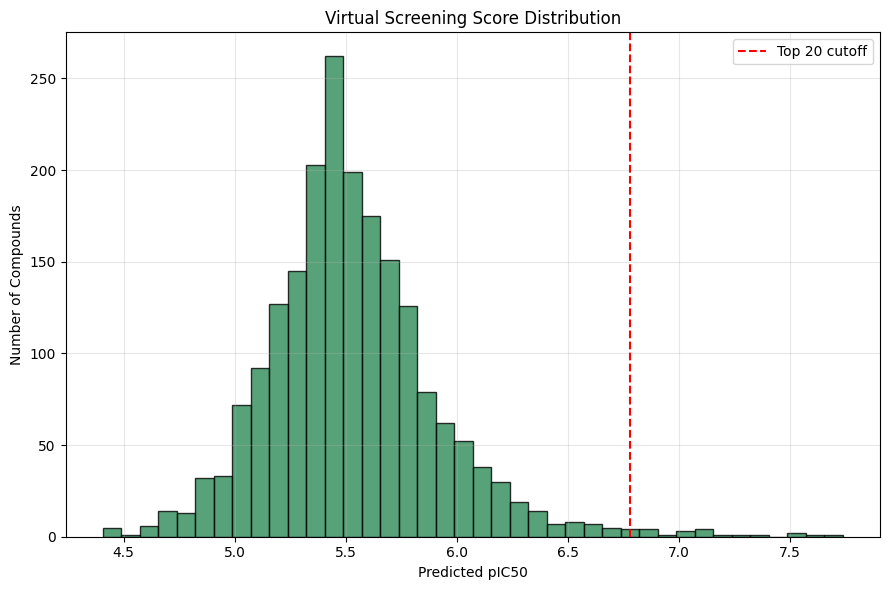

In [8]:
# Block 8: Rank virtual screening hits and apply drug-likeness filters

print("="*60)
print("RANKING AND FILTERING VIRTUAL SCREENING HITS")
print("="*60)

df_screen['Lipinski_Pass'] = (
    (df_screen['MolWt'] <= 500) &
    (df_screen['LogP'] <= 5) &
    (df_screen['HBD'] <= 5) &
    (df_screen['HBA'] <= 10)
)

df_ranked = df_screen.sort_values(
    'Predicted_pIC50', ascending=False
).reset_index(drop=True)
df_ranked.index = df_ranked.index + 1

top_hits = df_ranked.head(20)

print(f"Top 20 virtual screening hits (ranked by predicted pIC50):")
print(top_hits[['COCONUT_ID', 'Predicted_pIC50', 'MolWt',
                 'LogP', 'Lipinski_Pass']].to_string())

drug_like_hits = df_ranked[df_ranked['Lipinski_Pass'] == True].head(10)
print(f"\nTop 10 drug-like hits (Predicted_pIC50 rank + Lipinski pass):")
print(drug_like_hits[['COCONUT_ID', 'Predicted_pIC50',
                       'MolWt', 'LogP']].to_string())

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(df_screen['Predicted_pIC50'], bins=40, color='seagreen',
        edgecolor='black', alpha=0.8)
ax.axvline(x=top_hits['Predicted_pIC50'].min(), color='red',
           linestyle='--', label='Top 20 cutoff')
ax.set_xlabel('Predicted pIC50')
ax.set_ylabel('Number of Compounds')
ax.set_title('Virtual Screening Score Distribution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Meaning of Block 8:

Purpose: Convert the raw predicted scores into an actionable, prioritized shortlist by ranking all compounds and applying drug-likeness filtering.

What data comes IN: df_screen from Block 7.

What comes OUT: df_ranked — the fully ranked screening library. top_hits, drug_like_hits — prioritized shortlists ready for further investigation.

In [9]:
# Block 9: DEPLOYMENT BLOCK
# Screen any compound against the trained QSAR scoring model

print("="*70)
print("VIRTUAL SCREENING TOOL")
print("="*70)
print("""
********************************************************************
*   The value below is a DEMONSTRATION VALUE ONLY.                 *
*   TO SCREEN YOUR OWN COMPOUND:                                   *
*   1. Scroll to "STUDENT INPUT SECTION" below                     *
*   2. REPLACE new_compound_name and new_compound_smiles           *
*   3. Do NOT change anything below "END OF INPUT SECTION"         *
*   4. Then run this cell again                                    *
*   REQUIREMENT: Blocks 1-4 must already have run in this session. *
********************************************************************
""")

# ============================================================
# STUDENT INPUT SECTION - EDIT EVERYTHING BELOW THIS LINE
# ============================================================

new_compound_name = "My_Test_Compound"          # <-- EDIT: type your compound's name

new_compound_smiles = "COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O"
# <-- EDIT: replace with YOUR compound's SMILES (demo value is Curcumin)

# ============================================================
# END OF INPUT SECTION - DO NOT EDIT ANYTHING BELOW THIS LINE
# ============================================================

print(f"\nCompound name entered: {new_compound_name}")
print(f"SMILES entered: {new_compound_smiles}")
if new_compound_name == "My_Test_Compound":
    print("*** WARNING: Still using DEMONSTRATION value. ***")

mol_check = Chem.MolFromSmiles(new_compound_smiles)

if mol_check is None:
    print("\nERROR: Invalid SMILES.")
else:
    new_desc = calculate_descriptors(new_compound_smiles)
    new_fp = get_fingerprint(new_compound_smiles)
    new_features = np.hstack(
        [[new_desc[c] for c in desc_cols], new_fp]
    ).reshape(1, -1)

    predicted_pIC50 = scoring_model.predict(new_features)[0]

    print(f"\n{'='*60}")
    print(f"VIRTUAL SCREENING RESULT: {new_compound_name}")
    print(f"{'='*60}")
    print(f"Predicted pIC50: {predicted_pIC50:.2f}")

    percentile = (df_screen['Predicted_pIC50'] < predicted_pIC50).mean() * 100
    print(f"Percentile rank vs screening library: {percentile:.1f}%")

    lipinski_new = (
        new_desc['MolWt'] <= 500 and new_desc['LogP'] <= 5 and
        new_desc['HBD'] <= 5 and new_desc['HBA'] <= 10
    )
    print(f"Lipinski Rule of Five: {'PASS' if lipinski_new else 'FAIL'}")

    if predicted_pIC50 >= top_hits['Predicted_pIC50'].min():
        print(f"\nThis compound would rank among the TOP 20 hits")
        print(f"in the screened natural product library.")

VIRTUAL SCREENING TOOL

********************************************************************
*   The value below is a DEMONSTRATION VALUE ONLY.                 *
*   TO SCREEN YOUR OWN COMPOUND:                                   *
*   1. Scroll to "STUDENT INPUT SECTION" below                     *
*   2. REPLACE new_compound_name and new_compound_smiles           *
*   3. Do NOT change anything below "END OF INPUT SECTION"         *
*   4. Then run this cell again                                    *
*   REQUIREMENT: Blocks 1-4 must already have run in this session. *
********************************************************************


Compound name entered: My_Test_Compound
SMILES entered: COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O
*** WARNING: Still using DEMONSTRATION value. ***

VIRTUAL SCREENING RESULT: My_Test_Compound
Predicted pIC50: 4.97
Percentile rank vs screening library: 4.6%
Lipinski Rule of Five: PASS


Meaning of Block 9:

Purpose: A complete virtual screening tool where a student inputs any compound and receives its predicted activity, percentile rank against the screened library, and drug-likeness status.

What data comes IN: Student-typed compound. scoring_model, calculate_descriptors, get_fingerprint, df_screen, top_hits from previous blocks.

What comes OUT: A complete virtual screening result for any compound a student chooses to evaluate.